# 2. 봉인 전 탐색
날짜 정책은 스크립트의 날짜표를 사용합니다. 모든 목표 통계는 ≤2021-08-31이고 복사·suspect·정전점을 제외합니다.

In [1]:
from pathlib import Path
import os
from datetime import date
import json
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams['font.family'] = 'NanumSquare'
plt.rcParams['axes.unicode_minus'] = False
DATA = Path('../5. 자원 최적화 AI 데이터셋')
RESULTS = Path(os.environ.get('KAMP_RESULTS', os.environ.get('GMST_RESULTS', '../results')))
import numpy as np
df = pl.read_csv(DATA / 'okm_15min_2021.csv').with_columns(pl.col('datetime').str.strptime(pl.Datetime, '%Y.%m.%d %H:%M:%S'))
df = df.with_columns(pl.col('datetime').dt.date().alias('date'), (pl.col('datetime').dt.hour() * 4 + pl.col('datetime').dt.minute() // 15).alias('quarter'))
df = df.filter(pl.col('date') <= date(2021, 8, 31))
days = pl.read_csv(DATA / 'okm_cv_splits_2021.csv', try_parse_dates=True)
print('비가동일 수:', days.filter(~pl.col('is_operating')).height)
clean = df.join(days.select('date', 'is_copy', 'is_suspect', 'is_operating', 'daytype'), on='date').filter(~pl.col('is_copy') & ~pl.col('is_suspect') & ~pl.col('is_missing'))
summer = clean.filter(pl.col('date') >= date(2021, 7, 1))
display(days.group_by('copy_kind').len())


비가동일 수: 62


copy_kind,len
str,u32
"""edited""",7
"""""",135
"""exact""",115


## Fold 일정

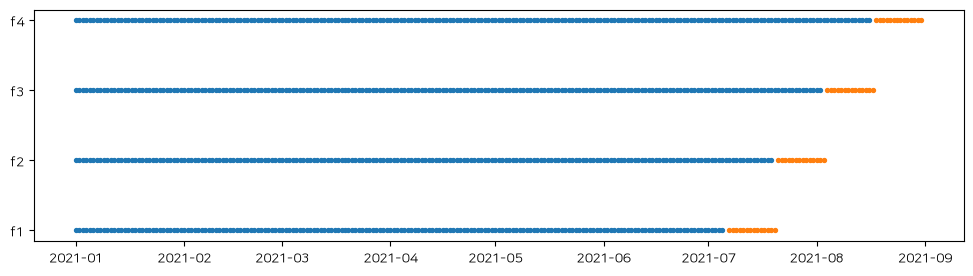

In [2]:
fig, ax = plt.subplots(figsize=(12, 3))
for j, fold in enumerate(('f1', 'f2', 'f3', 'f4')):
    for role, color in (('train', 'tab:blue'), ('val', 'tab:orange')):
        dates = days.filter(pl.col(fold) == role)['date']
        ax.scatter(dates, [j] * len(dates), s=8, color=color)
ax.set_yticks(range(4), ('f1', 'f2', 'f3', 'f4'))
plt.show()


## 6. 가동·요일·슬롯 설명력

In [3]:
cell = summer.group_by('is_operating', 'daytype', 'quarter').agg(pl.col('전력').mean().alias('cell_mean'))
r = summer.join(cell, on=['is_operating', 'daytype', 'quarter'])
y = r['전력'].to_numpy()
r2 = 1 - np.square(y-r['cell_mean'].to_numpy()).sum()/np.square(y-y.mean()).sum()
print('7–8월 가동×요일×슬롯 R²:', r2)


7–8월 가동×요일×슬롯 R²: 0.9231846487125611


## 8. 전력 분포
100빈+5빈 이동평균에서 센 10개 모드는 잔물결이다(v2 §4.4). 원 전력의 세 봉우리는 잔차 상태 수의 식별 근거와 다릅니다.

10단위 빈 3봉: 20–30대 2082 / 100–110대 569 / 170–180대 326


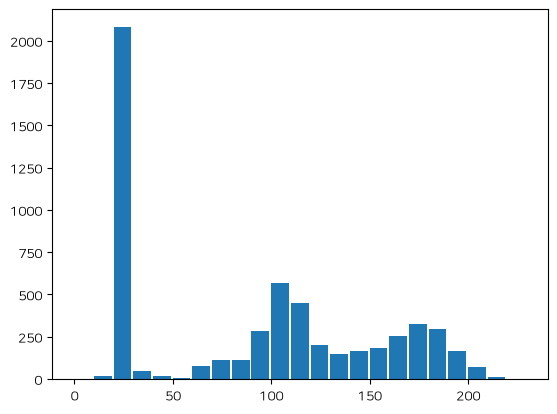

In [4]:
counts, edges = np.histogram(summer['전력'].to_numpy(), bins=np.arange(0, 240, 10))
print(f'10단위 빈 3봉: 20–30대 {counts[2]} / 100–110대 {counts[10]} / 170–180대 {counts[17]}')
plt.bar(edges[:-1], counts, width=9, align='edge')
plt.show()


## 11. 시간 의존성
lag-1 두 행은 가동플래그 정의가 달라 직접 비교하지 않습니다. H=96 슬라이딩 초과는 자정 정렬 예측과 다르고 가동·비가동 체제를 섞습니다(v2 §4.5).

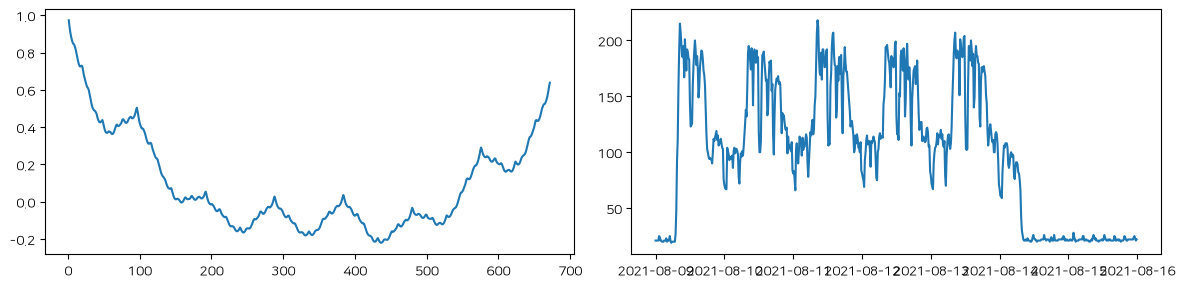

7–8월 동행 상관
f64
0.604777


In [5]:
timeline = df.join(days.select('date', 'is_copy', 'is_suspect'), on='date').with_columns(pl.when(pl.col('is_copy') | pl.col('is_suspect') | pl.col('is_missing')).then(None).otherwise(pl.col('전력')).alias('전력'))
y = timeline['전력'].to_numpy()
lags = np.arange(1, 673)
acf = []
for lag in lags:
    valid = np.isfinite(y[lag:]) & np.isfinite(y[:-lag])
    acf.append(np.corrcoef(y[lag:][valid], y[:-lag][valid])[0,1])
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(lags, acf)
week = df.filter(pl.col('date').is_between(date(2021, 8, 9), date(2021, 8, 15)))
axes[1].plot(week['datetime'], week['전력'])
plt.tight_layout()
plt.show()
hourly = summer.group_by(pl.col('datetime').dt.truncate('1h')).agg(pl.col('전력').mean(), pl.col('생산량').first()).sort('datetime')
display(hourly.select(pl.corr('전력', '생산량').alias('7–8월 동행 상관')))
